In [4]:
import json
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

filepath = "data/episode_0001_success.json"

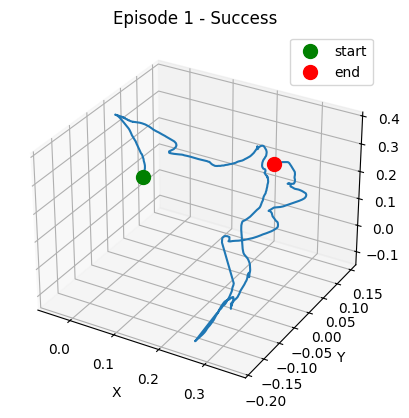

In [8]:
# Plot trajectories over time

with open(filepath) as f:
    episode = json.load(f)

transitions = episode["transition"]
xs = [t["ee_position"][0] for t in transitions]
ys = [t["ee_position"][1] for t in transitions]
zs = [t["ee_position"][2] for t in transitions]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, ys, zs)
ax.scatter(xs[0], ys[0], zs[0], color='green', s=100, label='start')
ax.scatter(xs[-1], ys[-1], zs[-1], color='red', s=100, label='end')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.legend()
plt.title(f"Episode {episode['episode_id']} - {'Success' if episode['success'] else 'Failure'}")
plt.show()

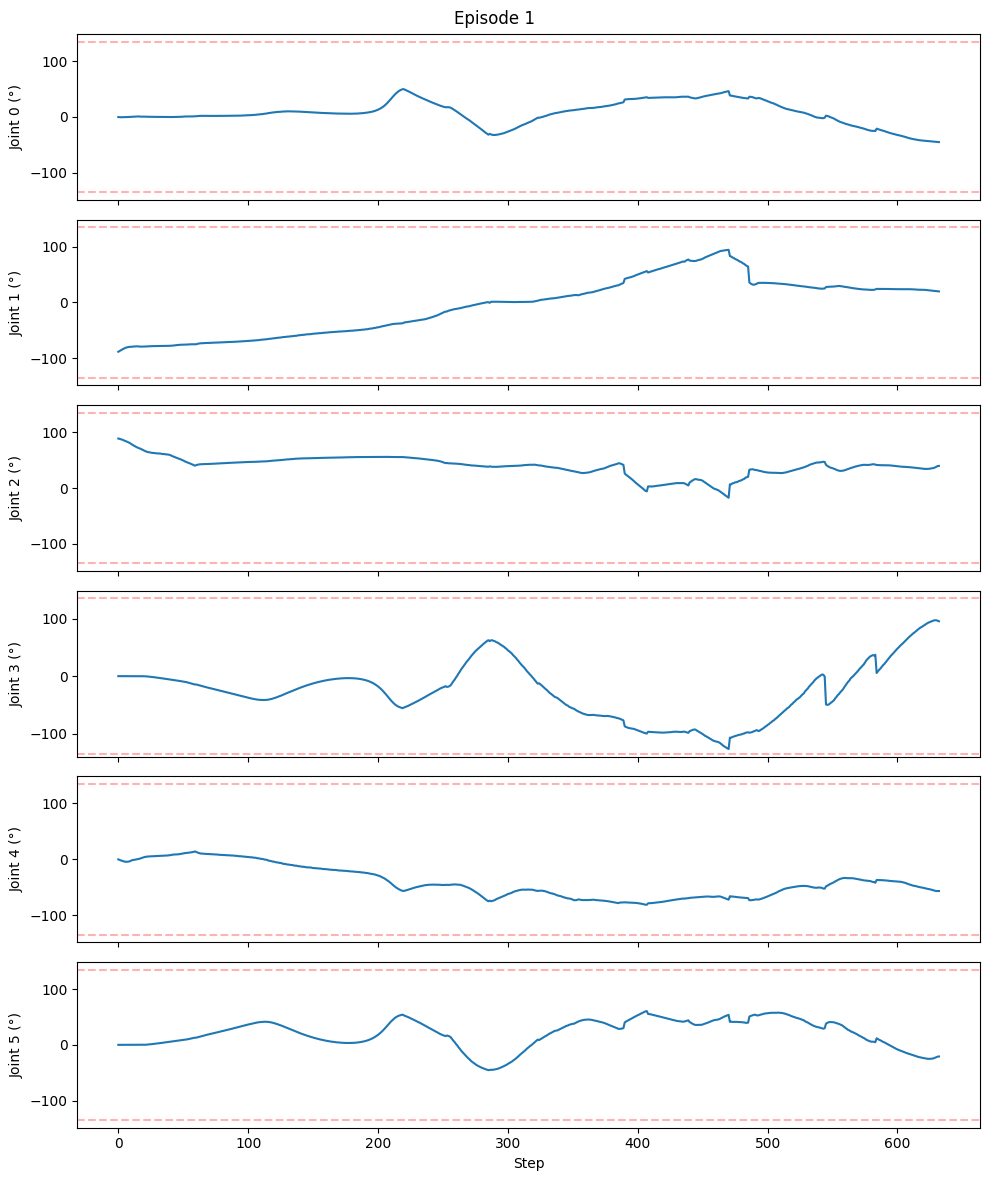

In [7]:
# Plot joint angles over time 

with open(filepath) as f:
    episode = json.load(f)

transitions = episode["transition"]
joint_data = [t["commanded_joint_angles"] for t in transitions]
joint_data = list(zip(*joint_data))  # transpose to per-joint lists

fig, axes = plt.subplots(6, 1, figsize=(10, 12), sharex=True)
for i, (ax, joint) in enumerate(zip(axes, joint_data)):
    ax.plot(joint)
    ax.set_ylabel(f"Joint {i} (°)")
    ax.axhline(y=135, color='r', linestyle='--', alpha=0.3)
    ax.axhline(y=-135, color='r', linestyle='--', alpha=0.3)
axes[-1].set_xlabel("Step")
plt.suptitle(f"Episode {episode['episode_id']}")
plt.tight_layout()
plt.show()